In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
diamond = sns.load_dataset('diamonds')

In [4]:
diamond.shape

(53940, 10)

In [5]:
diamond.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
df = diamond.drop(columns=['cut','color','clarity'],axis=1)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   carat   53940 non-null  float64
 1   depth   53940 non-null  float64
 2   table   53940 non-null  float64
 3   price   53940 non-null  int64  
 4   x       53940 non-null  float64
 5   y       53940 non-null  float64
 6   z       53940 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 2.9 MB


In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('price',axis=1)
y = df['price']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [12]:
preds = lr.predict(X_test)

In [13]:
preds,y_test.values

(array([ 200.79413447, 2361.44322401, 1051.27692119, ...,  604.32190045,
        7400.29315766, 5694.18353911]),
 array([ 559, 2201, 1238, ...,  761, 9836, 3742]))

In [15]:
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(preds,y_test))

888.4808633901026


### Feature Importance

We use `permutation_importance` to evaluate the importance of each feature in the `LinearRegression` model. This method works by shuffling individual features and observing the drop in model performance. A higher drop indicates greater importance.

In [16]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    lr,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

In [18]:
result

{'importances_mean': array([4651.79144437,   68.94133982,   51.78128666, 1096.29658155,
          -6.20514116,   -5.49795071]),
 'importances_std': array([24.51395608,  2.96124349,  1.14843407,  3.97655357,  0.21786224,
         0.24185675]),
 'importances': array([[4677.19055614, 4653.52797446, 4676.14698904, 4611.25267536,
         4640.83902684],
        [  71.9538896 ,   65.02336655,   65.67861346,   71.23365089,
           70.81717858],
        [  51.73876444,   50.47973423,   53.42306933,   52.67139651,
           50.5934688 ],
        [1093.81078781, 1100.43591786, 1099.40333558, 1098.08593463,
         1089.74693188],
        [  -6.07995514,   -6.17153238,   -5.95070928,   -6.22413128,
           -6.59937773],
        [  -5.42300146,   -5.4437802 ,   -5.1579262 ,   -5.56185242,
           -5.90319325]])}

The `result` object contains the importance scores, including the mean importance and standard deviation across multiple repeats. We then organize these results into a DataFrame and sort them to easily identify the most influential features.

Finally, we visualize the permutation feature importance using a horizontal bar chart, showing the relative importance of each feature in predicting diamond prices.

In [19]:
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values(by="importance_mean", ascending=True)

importance_df

,feature,importance_mean,importance_std
4,y,-6.205141,0.217862
5,z,-5.497951,0.241857
2,table,51.781287,1.148434
1,depth,68.941340,2.961243
3,x,1096.296582,3.976554
0,carat,4651.791444,24.513956


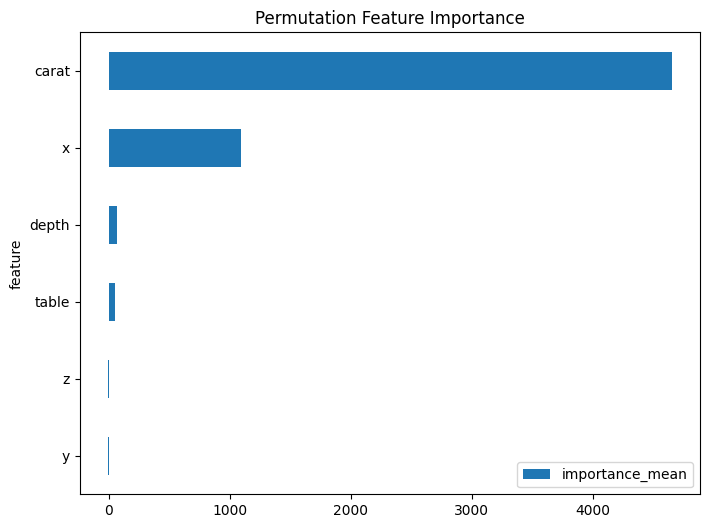

In [20]:
import matplotlib.pyplot as plt

importance_df.head(15).plot(
    x="feature",
    y="importance_mean",
    kind="barh",
    figsize=(8,6)
)

plt.title("Permutation Feature Importance")
plt.show()
